# 🎙️ Gender Classification from Voice — v2 (Fixed)

**Perbaikan dari v1:**
- ✅ Fitur diperbanyak: `pitch_range`, `voiced_ratio`, `mfcc_std`, `delta_mfcc`, `spectral_rolloff`, `zcr`
- ✅ Normalisasi durasi audio (crop tengah, tanpa silent padding)
- ✅ Tanpa `chroma_stft` (tidak relevan untuk gender)
- ✅ Pitch override di inference (`predict_gender_v2`)
- ✅ Blended scoring: 60% model + 40% pitch prior
- ✅ Hard override jika pitch > 200 Hz atau < 120 Hz

In [ ]:
# ── CELL 1 : Install dependencies ─────────────────────────────────────────
!pip install -q librosa numpy pandas scikit-learn xgboost matplotlib seaborn scipy praat-parselmouth

In [ ]:
# ── CELL 2 : Imports & seeds ───────────────────────────────────────────────
import os, warnings, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import librosa
import joblib

from pathlib import Path
from scipy.stats import skew, kurtosis

from sklearn.model_selection   import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model      import LogisticRegression
from sklearn.svm               import SVC
from sklearn.ensemble          import RandomForestClassifier
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.metrics           import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print('✅ Imports OK')

✅ Imports OK


In [ ]:
# ── CELL 3 : Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DATA_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/data')
assert DATA_ROOT.exists(), f'❌ Folder tidak ditemukan: {DATA_ROOT}'
print(f'✅ Data root OK: {DATA_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data root OK: /content/drive/MyDrive/Colab Notebooks/data


In [ ]:
# # TEST AJA INI MAhh
# def discover_files(data_root):
#     records = []
#     for label in ('male', 'female'):
#         folder = data_root / label
#         if not folder.exists():
#             raise FileNotFoundError(f'Folder tidak ada: {folder}')
#         wavs = sorted(folder.glob('*.wav'))
#         print(f'  {label}: {len(wavs):,} file')
#         for p in wavs:
#             records.append({'path': str(p), 'label': label})
#     return pd.DataFrame(records)


# def get_audio_info(df):
#     """Tambahkan kolom sample_rate, duration_sec, dan flag under_3s."""
#     sample_rates = []
#     durations = []

#     for path in df['path']:
#         try:
#             y, sr = librosa.load(path, sr=None)  # sr=None = baca rate asli
#             duration = len(y) / sr
#         except Exception as e:
#             print(f'  ⚠️  Gagal baca {path}: {e}')
#             sr, duration = None, None

#         sample_rates.append(sr)
#         durations.append(round(duration, 3) if duration is not None else None)

#     df = df.copy()
#     df['sample_rate_hz'] = sample_rates
#     df['duration_sec']   = durations
#     df['under_3s']       = df['duration_sec'].apply(
#         lambda d: d < 3.0 if d is not None else None
#     )
#     return df


# def balance_dataset(df, random_state=42):
#     counts  = df['label'].value_counts()
#     min_cnt = counts.min()
#     print(f'  Sebelum: {counts.to_dict()}')
#     print(f'  Undersample ke {min_cnt:,} per kelas')
#     balanced = (
#         df.groupby('label', group_keys=False)
#           .apply(lambda g: g.sample(n=min_cnt, random_state=random_state))
#           .sample(frac=1, random_state=random_state)
#           .reset_index(drop=True)
#     )
#     print(f'  Sesudah: {balanced["label"].value_counts().to_dict()}')
#     return balanced


# # ── Main ──────────────────────────────────────────────────────────────────────
# print('📂 Mencari file ...')
# df_raw = discover_files(DATA_ROOT)

# print('\n🔍 Mengecek sample rate & durasi ...')
# df_raw = get_audio_info(df_raw)

# # Ringkasan sample rate
# print('\n📊 Distribusi Sample Rate:')
# print(df_raw['sample_rate_hz'].value_counts().to_string())

# # Laporan file < 3 detik
# short_files = df_raw[df_raw['under_3s'] == True]
# print(f'\n⏱️  File dengan durasi < 3 detik: {len(short_files):,} file')
# if not short_files.empty:
#     print(short_files[['path', 'label', 'sample_rate_hz', 'duration_sec']].to_string(index=False))

# print('\n⚖️  Balancing ...')
# df = balance_dataset(df_raw)
# print(f'\n✅ Total dataset setelah balancing: {len(df):,} sampel')

# # Cek ulang file < 3 detik di dataset yang sudah balanced
# short_balanced = df[df['under_3s'] == True]
# print(f'⏱️  File < 3 detik setelah balancing: {len(short_balanced):,} file')

In [ ]:
# ── CELL 4 : Discover & balance files ─────────────────────────────────────
def discover_files(data_root):
    records = []
    for label in ('male', 'female'):
        folder = data_root / label
        if not folder.exists():
            raise FileNotFoundError(f'Folder tidak ada: {folder}')
        wavs = sorted(folder.glob('*.wav'))
        print(f'  {label}: {len(wavs):,} file')
        for p in wavs:
            records.append({'path': str(p), 'label': label})
    return pd.DataFrame(records)

def balance_dataset(df, random_state=42):
    counts  = df['label'].value_counts()
    min_cnt = counts.min()
    print(f'  Sebelum: {counts.to_dict()}')
    print(f'  Undersample ke {min_cnt:,} per kelas')
    balanced = (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(n=min_cnt, random_state=random_state))
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )
    print(f'  Sesudah: {balanced["label"].value_counts().to_dict()}')
    return balanced

print('📂 Mencari file ...')
df_raw = discover_files(DATA_ROOT)
print('\n⚖️  Balancing ...')
df = balance_dataset(df_raw)
print(f'\n✅ Total dataset setelah balancing: {len(df):,} sampel')

📂 Mencari file ...
  male: 10,380 file
  female: 5,768 file

⚖️  Balancing ...
  Sebelum: {'male': 10380, 'female': 5768}
  Undersample ke 5,768 per kelas
  Sesudah: {'female': 5768, 'male': 5768}

✅ Total dataset setelah balancing: 11,536 sampel


In [ ]:
# ── CELL 5 : Feature extraction v2 ────────────────────────────────────────
#
# Fitur baru dibanding v1:
#   + pitch_range, voiced_ratio
#   + mfcc_std (per koefisien)
#   + delta_mfcc (temporal change)
#   + spectral_rolloff
#   + zcr_mean
# Fitur yang TIDAK dipakai: chroma_stft, tonnetz, spectral_contrast
# Total fitur: ~58

# ── Path Google Drive ──────────────────────────────────────────────────────
FEAT_DIR = Path('/content/drive/MyDrive/results_v2/fitur/52')
FEAT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = FEAT_DIR / 'features_v2.csv'

# ──────────────────────────────────────────────────────────────────────────

def extract_features(wav_path: str, n_mfcc: int = 13):
    """
    Ekstrak fitur dari satu file .wav.
    Return None jika file tidak bisa dibaca atau terlalu pendek.
    """
    try:
        y, sr = librosa.load(wav_path, sr=16000, mono=True)
    except Exception as e:
        print(f'  ⚠️  Gagal load: {wav_path} — {e}')
        return None

    if len(y) < 512:
        return None

    # ── Normalisasi durasi: crop bagian tengah ke 3 detik ─────────────────
    target_len = sr * 3
    if len(y) > target_len:
        start = (len(y) - target_len) // 2
        y = y[start : start + target_len]

    feats = {}

    # ════════════════════════════════════════════════════════════════════════
    # 1. PITCH FEATURES
    # ════════════════════════════════════════════════════════════════════════
    try:
        snd   = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=50, pitch_ceiling=500)
        f0    = pitch.selected_array['frequency']
        f0    = f0[f0 > 0]
    except Exception:
        f0, voiced_flag, _ = librosa.pyin(
            y, fmin=50, fmax=500, frame_length=2048, hop_length=512
        )
        f0 = f0[~np.isnan(f0)] if f0 is not None else np.array([])

    if len(f0) == 0:
        f0 = np.array([0.0])

    feats['pitch_mean']     = float(np.mean(f0))
    feats['pitch_std']      = float(np.std(f0))
    feats['pitch_min']      = float(np.min(f0))
    feats['pitch_max']      = float(np.max(f0))
    feats['pitch_range']    = float(np.max(f0) - np.min(f0))
    feats['pitch_skew']     = float(skew(f0))
    feats['pitch_kurtosis'] = float(kurtosis(f0))

    durasi = len(y) / sr
    feats['voiced_ratio'] = float(len(f0) / max(durasi, 1e-6))

    # ════════════════════════════════════════════════════════════════════════
    # 2. MFCC + STD + DELTA
    # ════════════════════════════════════════════════════════════════════════
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)

    for i in range(n_mfcc):
        feats[f'mfcc_{i+1}_mean']  = float(np.mean(mfcc[i]))
        feats[f'mfcc_{i+1}_std']   = float(np.std(mfcc[i]))
        feats[f'delta_{i+1}_mean'] = float(np.mean(delta[i]))

    # ════════════════════════════════════════════════════════════════════════
    # 3. SPECTRAL FEATURES
    # ════════════════════════════════════════════════════════════════════════
    feats['spectral_centroid']  = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    feats['spectral_bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
    feats['spectral_rolloff']   = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))

    # ════════════════════════════════════════════════════════════════════════
    # 4. ENERGY & VOICE TEXTURE
    # ════════════════════════════════════════════════════════════════════════
    feats['rms_energy'] = float(np.mean(librosa.feature.rms(y=y)))
    feats['zcr_mean']   = float(np.mean(librosa.feature.zero_crossing_rate(y)))

    # ════════════════════════════════════════════════════════════════════════
    # 5. CLEANING
    # ════════════════════════════════════════════════════════════════════════
    feats = {k: float(np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0))
             for k, v in feats.items()}
    return feats


def build_feature_matrix(df, cache_path=CACHE_PATH):
    """Ekstrak fitur semua file, simpan ke CSV sebagai cache di Google Drive."""
    if os.path.exists(cache_path):
        print(f'📂 Memuat cache dari Drive: {cache_path}')
        return pd.read_csv(cache_path)

    print(f'🔊 Ekstraksi fitur dari {len(df):,} file ...')
    rows, failed = [], 0
    for i, row in df.iterrows():
        feats = extract_features(row['path'])
        if feats is None:
            failed += 1
            continue
        feats['label'] = row['label']
        rows.append(feats)
        if (i + 1) % 500 == 0:
            print(f'  {i+1:,} / {len(df):,} selesai ...')

    fdf = pd.DataFrame(rows)
    fdf.replace([np.inf, -np.inf], np.nan, inplace=True)
    fdf.fillna(fdf.median(numeric_only=True), inplace=True)

    # ── Simpan ke Google Drive ─────────────────────────────────────────────
    fdf.to_csv(cache_path, index=False)
    print(f'\n✅ Selesai. Shape: {fdf.shape} | Gagal: {failed} file')
    print(f'💾 Cache tersimpan di: {cache_path}')
    return fdf


# ── Cek cache di Google Drive ──────────────────────────────────────────────
if os.path.exists(CACHE_PATH):
    print(f'🗑️  Cache v2 ditemukan di Drive: {CACHE_PATH}')
    print('   Hapus file tersebut jika ingin ekstrak ulang.')
else:
    print('🆕 Belum ada cache di Drive, akan ekstrak fitur baru ...')

feature_df = build_feature_matrix(df, cache_path=CACHE_PATH)
print(f'\nJumlah fitur: {feature_df.shape[1] - 1}')
print(f'Kolom fitur: {[c for c in feature_df.columns if c != "label"]}')

🆕 Belum ada cache di Drive, akan ekstrak fitur baru ...
🔊 Ekstraksi fitur dari 11,536 file ...
  500 / 11,536 selesai ...
  1,000 / 11,536 selesai ...
  1,500 / 11,536 selesai ...
  2,000 / 11,536 selesai ...
  2,500 / 11,536 selesai ...
  3,000 / 11,536 selesai ...
  3,500 / 11,536 selesai ...
  4,000 / 11,536 selesai ...
  4,500 / 11,536 selesai ...
  5,000 / 11,536 selesai ...
  5,500 / 11,536 selesai ...
  6,000 / 11,536 selesai ...
  6,500 / 11,536 selesai ...
  7,000 / 11,536 selesai ...
  7,500 / 11,536 selesai ...
  8,000 / 11,536 selesai ...
  8,500 / 11,536 selesai ...
  9,000 / 11,536 selesai ...
  9,500 / 11,536 selesai ...
  10,000 / 11,536 selesai ...
  10,500 / 11,536 selesai ...
  11,000 / 11,536 selesai ...
  11,500 / 11,536 selesai ...

✅ Selesai. Shape: (11536, 53) | Gagal: 0 file
💾 Cache tersimpan di: /content/drive/MyDrive/results_v2/fitur/52/features_v2.csv

Jumlah fitur: 52
Kolom fitur: ['pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range', 'pitch_s

=== Distribusi Pitch di Data ===
         count        mean        std         min         25%         50%  \
label                                                                       
female  5768.0  195.674319  20.822119  138.780809  180.085301  188.326752   
male    5768.0  128.848313  20.881158   84.392486  113.818988  127.104007   

               75%         max  
label                           
female  212.078878  277.271352  
male    142.124414  205.989158  


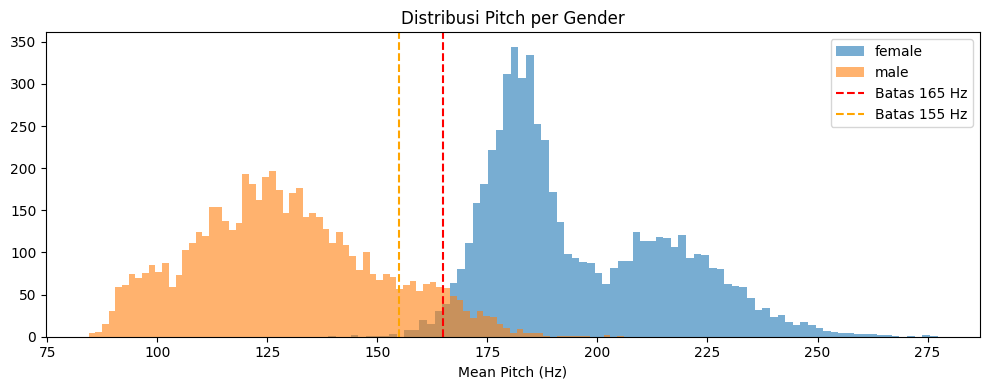

In [ ]:
# ── CELL 6 : Cek distribusi pitch (sanity check) ───────────────────────────
print('=== Distribusi Pitch di Data ===')
print(feature_df.groupby('label')['pitch_mean'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in feature_df.groupby('label'):
    ax.hist(grp['pitch_mean'], bins=80, alpha=0.6, label=label)
ax.axvline(165, color='red',    linestyle='--', label='Batas 165 Hz')
ax.axvline(155, color='orange', linestyle='--', label='Batas 155 Hz')
ax.set_xlabel('Mean Pitch (Hz)')
ax.set_title('Distribusi Pitch per Gender')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 7 : Stratified split 70 / 10 / 20 ────────────────────────────────
label_col = 'label'
feat_cols = [c for c in feature_df.columns if c != label_col]

le = LabelEncoder()                     # female=0, male=1
y  = le.fit_transform(feature_df[label_col])
X  = feature_df[feat_cols].values

# Tahap 1: pisahkan 20% test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# Tahap 2: sisanya 87.5% train + 12.5% val = 70% + 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.125, stratify=y_tmp, random_state=42
)

print(f'Train : {len(y_train):,} sampel')
print(f'Val   : {len(y_val):,} sampel')
print(f'Test  : {len(y_test):,} sampel')
print(f'Label : {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train : 8,074 sampel
Val   : 1,154 sampel
Test  : 2,308 sampel
Label : {'female': np.int64(0), 'male': np.int64(1)}


In [ ]:
# ── CELL 8 : Preprocessing (scaler + SelectKBest) ─────────────────────────
# PENTING: fit hanya pada data training, transform val & test

# K = 45  # jumlah fitur terbaik (30–50)

# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)   # fit di train
# X_val_s   = scaler.transform(X_val)
# X_test_s  = scaler.transform(X_test)

# selector  = SelectKBest(f_classif, k=min(K, X_train_s.shape[1]))
# X_train_s = selector.fit_transform(X_train_s, y_train)  # fit di train
# X_val_s   = selector.transform(X_val_s)
# X_test_s  = selector.transform(X_test_s)

# selected  = [feat_cols[i] for i in selector.get_support(indices=True)]
# print(f'Fitur dipilih: {len(selected)}')
# print(f'Top 10: {selected[:10]}')

# ── CELL 8 : Preprocessing (scaler only, no feature selection) ────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Semua fitur dipakai
selected = feat_cols
print(f'Jumlah fitur dipakai: {len(selected)}')
print(f'Top 10: {selected[:10]}')

Jumlah fitur dipakai: 52
Top 10: ['pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range', 'pitch_skew', 'pitch_kurtosis', 'voiced_ratio', 'mfcc_1_mean', 'mfcc_1_std']


In [ ]:
# ── CELL 9 : Training + Tuning + Kalibrasi ────────────────────────────────
OVERFIT_THRESHOLD = 0.10
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'SVM': {
        'est': SVC(probability=True, random_state=42),
        'params': {
            'C':      [0.1, 0.5, 1.0, 5.0, 10.0],
            'kernel': ['rbf', 'linear'],
            'gamma':  ['scale', 'auto'],
        },
    },
    'XGBoost': {
        'est': XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1
        ),
        'params': {
            'n_estimators':     [100, 200, 300],
            'max_depth':        [3, 4, 5, 6],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'subsample':        [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'reg_alpha':        [0, 0.1, 0.5, 1.0],
            'reg_lambda':       [1.0, 2.0, 5.0],
        },
    },
}

trained = {}
for name, cfg in model_configs.items():
    print(f'\n🏋️  Tuning {name} ...')
    search = RandomizedSearchCV(
        cfg['est'], cfg['params'],
        n_iter=20, cv=CV, scoring='f1',
        refit=True, n_jobs=-1,
        random_state=42, verbose=0
    )
    search.fit(X_train_s, y_train)
    best     = search.best_estimator_
    train_f1 = f1_score(y_train, best.predict(X_train_s))
    val_f1   = f1_score(y_val,   best.predict(X_val_s))
    gap      = train_f1 - val_f1

    print(f'   Params   : {search.best_params_}')
    print(f'   Train F1 : {train_f1:.4f}')
    print(f'   Val F1   : {val_f1:.4f}')
    print(f'   Gap      : {gap:.4f}', end='  ')

    if gap > OVERFIT_THRESHOLD:
        print(f'❌ OVERFIT → {name} ditolak')
        continue
    print('✅')

    cal = CalibratedClassifierCV(best, cv='prefit', method='sigmoid')
    cal.fit(X_val_s, y_val)
    trained[name] = {'model': cal, 'train_f1': train_f1, 'val_f1': val_f1, 'gap': gap}
    print(f'   ✅ Dikalibrasi dan disimpan.')

print(f'\nModel diterima: {list(trained.keys())}')


🏋️  Tuning SVM ...
   Params   : {'kernel': 'rbf', 'gamma': 'scale', 'C': 5.0}
   Train F1 : 1.0000
   Val F1   : 1.0000
   Gap      : 0.0000  ✅
   ✅ Dikalibrasi dan disimpan.

🏋️  Tuning XGBoost ...
   Params   : {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
   Train F1 : 1.0000
   Val F1   : 0.9965
   Gap      : 0.0035  ✅
   ✅ Dikalibrasi dan disimpan.

Model diterima: ['SVM', 'XGBoost']



── SVM
   Accuracy : 1.0000
   F1 Macro : 1.0000
   ROC-AUC  : 1.0000


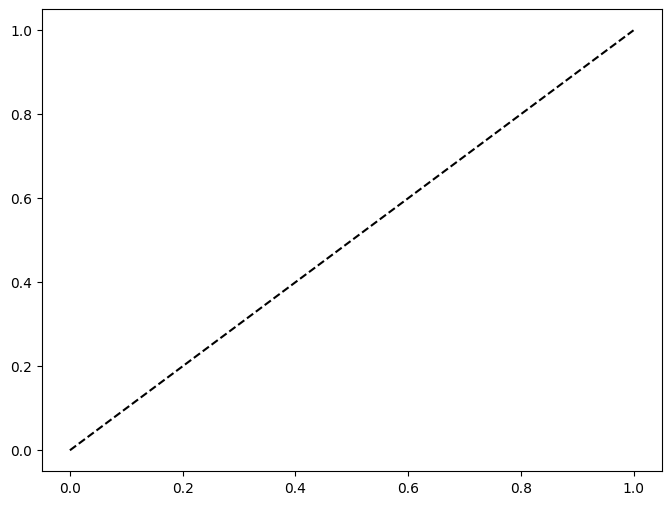

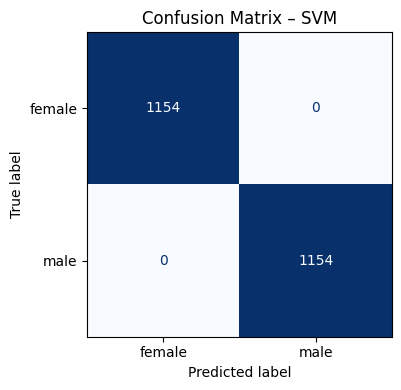


── XGBoost
   Accuracy : 0.9978
   F1 Macro : 0.9978
   ROC-AUC  : 1.0000


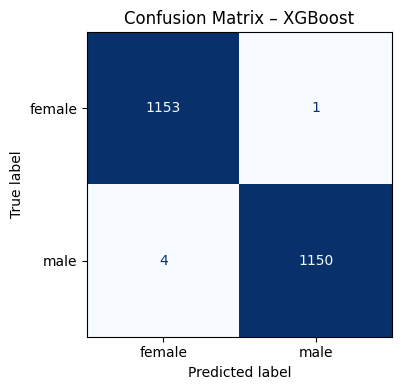


══ LEADERBOARD ══════════════════════════════════


,Accuracy,F1_Macro,ROC_AUC
SVM,1.000000,1.000000,1.000000
XGBoost,0.997834,0.997834,0.999983



🏆 Model terbaik: SVM


In [ ]:
# ── CELL 10 : Evaluasi di test set ────────────────────────────────────────
os.makedirs('results_v2', exist_ok=True)

# Arahkan PNG ke Google Drive
SAVE_DIR = Path('/content/drive/MyDrive/results_v2/52')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

results = {}
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot([0,1],[0,1],'k--', label='Chance')

for name, info in trained.items():
    mdl    = info['model']
    y_pred = mdl.predict(X_test_s)
    y_prob = mdl.predict_proba(X_test_s)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'F1_Macro': f1, 'ROC_AUC': auc}

    print(f'\n── {name}')
    print(f'   Accuracy : {acc:.4f}')
    print(f'   F1 Macro : {f1:.4f}')
    print(f'   ROC-AUC  : {auc:.4f}')

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax_cm, colorbar=False, cmap='Blues'
    )
    ax_cm.set_title(f'Confusion Matrix – {name}')
    fig_cm.tight_layout()
    fig_cm.savefig(SAVE_DIR / f'cm_{name}.png', dpi=120)  # ← simpan ke Drive
    plt.show()
    plt.close(fig_cm)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves – Semua Model')
ax_roc.legend(loc='lower right')
fig_roc.tight_layout()
fig_roc.savefig(SAVE_DIR / 'roc_curves.png', dpi=120)  # ← simpan ke Drive
plt.show()

# Leaderboard
results_df = pd.DataFrame(results).T.sort_values('ROC_AUC', ascending=False)
print('\n══ LEADERBOARD ══════════════════════════════════')
display(results_df)

BEST_NAME  = results_df.index[0]
BEST_MODEL = trained[BEST_NAME]['model']
print(f'\n🏆 Model terbaik: {BEST_NAME}')

In [ ]:
# @title
def predict_gender_v2(wav_path):
    """
    Prediksi gender dari satu file .wav.
    Menggunakan: BEST_MODEL, scaler, selector, le, feat_cols
    """
    feats = extract_features(wav_path)
    if feats is None:
        return {'error': f'Tidak bisa ekstrak fitur dari {wav_path}'}

    # Susun vektor fitur sesuai urutan training
    row = np.array([feats.get(col, 0.0) for col in feat_cols], dtype=float)
    row = np.nan_to_num(row, nan=0.0, posinf=0.0, neginf=0.0).reshape(1, -1)
    row = scaler.transform(row)

    if selector is not None:
        row = selector.transform(row)

    # Probabilitas dari model
    proba       = BEST_MODEL.predict_proba(row)[0]
    classes     = list(le.classes_)  # ['female', 'male']

    prob_female = float(proba[classes.index('female')])
    prob_male   = float(proba[classes.index('male')])
    avg_pitch   = feats.get('pitch_mean', 0.0)

    # ── Pitch prior ─────────────────────────
    if avg_pitch >= 165:
        pitch_pf = min(0.95, 0.60 + (avg_pitch - 165) / 200)
        pitch_pm = 1 - pitch_pf
    elif 0 < avg_pitch <= 155:
        pitch_pm = min(0.95, 0.60 + (155 - avg_pitch) / 150)
        pitch_pf = 1 - pitch_pm
    else:
        pitch_pf = prob_female
        pitch_pm = prob_male

    # ── Blended score ───────────────────────
    ALPHA, BETA = 0.60, 0.40
    blended_f = ALPHA * prob_female + BETA * pitch_pf
    blended_m = ALPHA * prob_male   + BETA * pitch_pm

    total = blended_f + blended_m
    blended_f /= total
    blended_m /= total

    # ✔ FIX
    isWoman = blended_f > blended_m

    keterangan = None

    # ── Hard override ───────────────────────
    if avg_pitch > 200:
        final_label = 'female'
        blended_f   = max(blended_f, 0.75)
        blended_m   = 1 - blended_f

        if not isWoman:
            keterangan = f'⚠️ Pitch {avg_pitch:.1f} Hz sangat tinggi → OVERRIDE ke FEMALE'

    elif 0 < avg_pitch < 120:
        final_label = 'male'
        blended_m   = max(blended_m, 0.75)
        blended_f   = 1 - blended_m

        if isWoman:
            keterangan = f'⚠️ Pitch {avg_pitch:.1f} Hz sangat rendah → OVERRIDE ke MALE'

    else:
        final_label = 'female' if blended_f > blended_m else 'male'

    result = {
        'label':       final_label,
        'prob_male':   round(blended_m,   4),
        'prob_female': round(blended_f,   4),
        'avg_pitch':   round(avg_pitch,   2),
        'model_raw':   f'male={prob_male:.2f} / female={prob_female:.2f}',
        'keterangan':  keterangan
    }

    print(f'\n🎤 File          : {wav_path}')
    print(f'   Model Raw    : male={prob_male*100:.1f}% / female={prob_female*100:.1f}%')
    print(f'   Avg Pitch    : {avg_pitch:.1f} Hz')
    print(f'   Final Result : {final_label.upper()} '
          f'(male={blended_m*100:.1f}% / female={blended_f*100:.1f}%)')

    if keterangan:
        print(f'   {keterangan}')

    return result


print('✅ Fungsi predict_gender_v2 siap digunakan')


✅ Fungsi predict_gender_v2 siap digunakan


In [ ]:
# @title
# ── CELL 12 : Test dengan 1 file audio ────────────────────────────────────
# Ganti path ini dengan file .wav milikmu

TEST_FILE = '/content/test_human.wav'   # ← ganti path di sini

if os.path.exists(TEST_FILE):
    result = predict_gender_v2(TEST_FILE)
else:
    print(f'❌ File tidak ditemukan: {TEST_FILE}')
    print('   Ganti path TEST_FILE dengan path yang benar')

❌ File tidak ditemukan: /content/test_human.wav
   Ganti path TEST_FILE dengan path yang benar


In [ ]:
# @title
# # ── CELL 13 : Upload file langsung dari komputer ───────────────────────────
# from google.colab import files

# print('📤 Klik tombol di bawah untuk upload file .wav dari komputer kamu:')
# uploaded = files.upload()

# for filename, content in uploaded.items():
#     with open(filename, 'wb') as f:
#         f.write(content)
#     print(f'\n📁 File diterima: {filename}')
#     result = predict_gender_v2(filename)

In [ ]:
# @title
# ── CELL 15 : Konversi MP3/M4A ke WAV (opsional) ──────────────────────────
# Jalankan jika file kamu bukan .wav

!pip install -q pydub
!apt-get install -q ffmpeg

from pydub import AudioSegment

def convert_to_wav(input_path: str) -> str:
    """
    Konversi file audio ke .wav.
    Mendukung: mp3, m4a, ogg, flac, dll.
    Return path file .wav hasil konversi.
    """
    ext      = os.path.splitext(input_path)[1].lower().replace('.', '')
    wav_path = input_path.replace(f'.{ext}', '.wav')
    audio    = AudioSegment.from_file(input_path, format=ext)
    audio.export(wav_path, format='wav')
    print(f'✅ Konversi selesai: {wav_path}')
    return wav_path

# Contoh penggunaan:
# wav_path = convert_to_wav('suara_saya.mp3')
# result   = predict_gender_v2(wav_path)

print('✅ Fungsi convert_to_wav siap. Uncomment baris di atas untuk digunakan.')

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
✅ Fungsi convert_to_wav siap. Uncomment baris di atas untuk digunakan.


In [ ]:


# Ganti SAVE_DIR ke path Google Drive
SAVE_DIR = Path('/content/drive/MyDrive/results_v2/52/pkl')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Kode simpan kamu — tidak perlu diubah sama sekali
joblib.dump(BEST_MODEL, SAVE_DIR / 'best_model_v2.pkl')
joblib.dump(scaler,     SAVE_DIR / 'scaler_v2.pkl')
joblib.dump(selector,   SAVE_DIR / 'selector_v2.pkl')
joblib.dump(le,         SAVE_DIR / 'label_encoder_v2.pkl')

with open(SAVE_DIR / 'feat_cols_v2.json', 'w') as f:
    json.dump(feat_cols, f)

results_df.to_csv(SAVE_DIR / 'leaderboard_v2.csv')

print('✅ Semua artefact tersimpan di:', SAVE_DIR)
print('   Files:', [str(p.name) for p in SAVE_DIR.iterdir()])

✅ Semua artefact tersimpan di: /content/drive/MyDrive/results_v2/52/pkl
   Files: ['best_model_v2.pkl', 'scaler_v2.pkl', 'selector_v2.pkl', 'label_encoder_v2.pkl', 'feat_cols_v2.json', 'leaderboard_v2.csv']


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

df = pd.read_csv('features_v2.csv')
X = df.drop('label', axis=1).values
y = (df['label'] == 'female').astype(int).values  # 0=male, 1=female

# Penting: simpan scaler untuk dipakai di Flutter juga
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simpan mean & std scaler (akan dipakai hardcode di Flutter)
np.save('scaler_mean.npy', scaler.mean_)
np.save('scaler_std.npy', scaler.scale_)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(52,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

# Convert ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('gender_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

FileNotFoundError: [Errno 2] No such file or directory: 'features_v2.csv'

In [ ]:
# Ganti SAVE_DIR ke path Google Drive
SAVE_DIR = Path('/content/drive/MyDrive/results_v2/52/joblib')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Simpan dengan ekstensi .joblib
joblib.dump(BEST_MODEL, SAVE_DIR / 'best_model_v2.joblib')
joblib.dump(scaler,     SAVE_DIR / 'scaler_v2.joblib')
joblib.dump(selector,   SAVE_DIR / 'selector_v2.joblib')
joblib.dump(le,         SAVE_DIR / 'label_encoder_v2.joblib')

with open(SAVE_DIR / 'feat_cols_v2.json', 'w') as f:
    json.dump(feat_cols, f)

results_df.to_csv(SAVE_DIR / 'leaderboard_v2.csv')

print('✅ Semua artefact tersimpan di:', SAVE_DIR)
print('   Files:', [str(p.name) for p in SAVE_DIR.iterdir()])

✅ Semua artefact tersimpan di: /content/drive/MyDrive/results_v2/52/joblib
   Files: ['best_model_v2.joblib', 'scaler_v2.joblib', 'selector_v2.joblib', 'label_encoder_v2.joblib', 'feat_cols_v2.json', 'leaderboard_v2.csv']
